# DraftSight — Prediction Tools

## Tools
1. **Trade Fairness Evaluator** — compare expected 2-year AV for two sides of a draft-pick trade  
2. **Player AV Predictor** — predict 2-year AV for a drafted player given their draft slot and profile

### Models used
- **XGBoost** (Tweedie loss, depth-6, tuned)
- **CatBoost** (Tweedie loss, depth-5, tuned)
- **Random Forest** (log-space target, depth-10, tuned)
- **Tree Ensemble** = equal-weight average of the three above

### Data setup for 2026
Before running with `PREDICT_YEAR = 2026`, add the 2026 picks to `drafts.csv` once:
```
python -m src.data.add_2026_draft
```
Context features (roster depth, vet AV) for 2026 will be filled with training-data medians
by the preprocessor — predictions are still valid, just slightly less precise than historical years.

In [12]:
import sys, os

# Add repo root to sys.path so both the notebook and train_n_evaluate.py
# can resolve `src.model_v6.*` imports consistently.
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

from src.model_v6.train_n_evaluate import (
    AV_MAX, LOG_PRED_CLIP,
    CATBOOST_CFG, RF_CFG, FTT_CFG, RANDOM_STATE, DEVICE,
    CFB_STAT_COLS, MODEL_NUM_COLS, MODEL_CAT_COLS, EXCLUDE_COLLEGE_STATS,
    DRAFTS_CSV, COLLEGE_STATS_CSV, ROSTER_CONTEXT_CSV,
    VET_PERF_CSV, DRAFT_POS_CONTEXT_CSV, PICK_TRADE_FLAGS_CSV,
    add_engineered_features, build_model_frame,
    build_tree_preprocessor, build_catboost_data, build_embed_data,
    train_embed_model, to_tensor,
    set_seeds,
)
from src.model_v6.ft_transformer import FTTransformer
from src.model_v6.data_loader import load_unlabeled_draft_class

set_seeds(RANDOM_STATE)
print('Imports OK')

Imports OK


## 1 · Configuration

In [13]:
# Draft class to predict.  Models train on all labeled years strictly before this.
# 2026 = current draft class (no AV labels yet).  2024 = most recent labeled class.
PREDICT_YEAR = 2026

# Set False after first run to reuse already-trained models (arts must still be in memory).
RETRAIN = True

# Smoothing bandwidth for the pick-value curve (in pick units).
PV_BANDWIDTH = 15

# Derived: years with known 2-year AV labels available for training
# av.csv goes to season 2025 → fully covered means draft_season + 1 ≤ 2025 → ≤ 2024
MAX_LABELED_YEAR = 2024

## 2 · Load labeled training data + target draft class

In [14]:
print('Loading labeled training data (years ≤ {}  )...'.format(MAX_LABELED_YEAR))
df_labeled = build_model_frame()
years_labeled = df_labeled['draft_season'].to_numpy(dtype=int)
print(f'  {len(df_labeled)} labeled picks, {years_labeled.min()}–{years_labeled.max()}')

has_labels = PREDICT_YEAR <= MAX_LABELED_YEAR

if has_labels:
    # Historical year: use the labeled data directly; pick out the target year as demo
    predict_df = df_labeled[years_labeled == PREDICT_YEAR].copy()
    train_df   = df_labeled[years_labeled < PREDICT_YEAR].copy()
    print(f'\nHistorical mode: predicting {PREDICT_YEAR} with known AV labels')
    print(f'  Training picks : {len(train_df)}')
    print(f'  Target picks   : {len(predict_df)}')
else:
    # Future year: train on everything labeled, load target class separately
    train_df = df_labeled.copy()
    print(f'\nPrediction mode: {PREDICT_YEAR} draft class (no AV labels)')
    print(f'  Training picks : {len(train_df)}')
    print(f'\nLoading {PREDICT_YEAR} draft class...')
    predict_df = load_unlabeled_draft_class(
        draft_year         = PREDICT_YEAR,
        drafts_csv         = DRAFTS_CSV,
        college_stats_csv  = COLLEGE_STATS_CSV,
        roster_context_csv = ROSTER_CONTEXT_CSV,
        pick_trade_flags_csv = PICK_TRADE_FLAGS_CSV,
        pos_context_csv    = DRAFT_POS_CONTEXT_CSV,
        vet_perf_csv       = VET_PERF_CSV,
    )
    print(f'  Target picks   : {len(predict_df)}')

Loading labeled training data (years ≤ 2024  )...
Loading draft: /Users/arnav/Desktop/STATS170A/DraftSight/data/supabase_exports/drafts.csv
Loading college stats: /Users/arnav/Desktop/STATS170A/DraftSight/data/supabase_exports/college_stats.csv
Loading AV: /Users/arnav/Desktop/STATS170A/DraftSight/data/supabase_exports/av.csv
Loading roster context: /Users/arnav/Desktop/STATS170A/DraftSight/data/supabase_exports/draft_pick_context_features.csv
Loading pick trade flags: /Users/arnav/Desktop/STATS170A/DraftSight/data/roster/pick_trade_flags.csv
Loading draft positional context: /Users/arnav/Desktop/STATS170A/DraftSight/data/roster/draft_positional_context_features.csv
Loading veteran performance: /Users/arnav/Desktop/STATS170A/DraftSight/data/roster/veteran_performance_features.csv
College stats join: {'total_picks': 12927, 'cs_window': (2005, 2026), 'picks_in_window': 5623, 'matched_total': 3395, 'matched_in_window': 3395, 'match_rate_overall': 0.26262860679198574, 'match_rate_in_window

## 3 · Fit production models

In [15]:
def _active_feat_cols(df_ref: pd.DataFrame) -> list:
    if EXCLUDE_COLLEGE_STATS:
        excl = set(CFB_STAT_COLS) | {'college_perf_score', 'cfb_matched'}
        active_num = [c for c in MODEL_NUM_COLS if c not in excl]
    else:
        active_num = list(MODEL_NUM_COLS)
    return [c for c in active_num + list(MODEL_CAT_COLS) if c in df_ref.columns]


def fit_tree_models(train_df: pd.DataFrame, predict_df: pd.DataFrame) -> dict:
    """
    Train XGB + CatBoost + RF + FTT on train_df.
    predict_df is passed only for add_engineered_features (no labels used from it).
    Returns a dict of fitted artifacts.
    """
    print('  Engineering features...', flush=True)
    train_aug, pred_aug, scorer = add_engineered_features(train_df, predict_df)

    y_orig = np.clip(train_aug['av_2yr'].to_numpy(dtype=float), 0, None)
    y_log  = np.log1p(y_orig)

    feat_cols = _active_feat_cols(train_aug)
    X_tr = train_aug[feat_cols].copy()
    X_pr = pred_aug[feat_cols].copy()

    arts: dict = {
        'feat_cols': feat_cols,
        'train_aug': train_aug,
        'pred_aug':  pred_aug,
        'scorer':    scorer,
        'y_orig':    y_orig,
        'X_pr':      X_pr,
    }

    # ── XGBoost ───────────────────────────────────────────────────────────────
    pre_x, _, _ = build_tree_preprocessor(X_tr)
    n_val = max(1, int(len(X_tr) * 0.15))
    X_t, X_v = X_tr.iloc[:-n_val], X_tr.iloc[-n_val:]
    y_t, y_v = y_orig[:-n_val], y_orig[-n_val:]
    xgb_pre = pre_x.fit(X_t)
    xgb_m = XGBRegressor(
        n_estimators=600, learning_rate=0.02, max_depth=6,
        min_child_weight=1, subsample=0.85, colsample_bytree=0.85,
        reg_lambda=3.0, nthread=1, random_state=RANDOM_STATE,
        objective='reg:tweedie', tweedie_variance_power=1.5,
        early_stopping_rounds=50, eval_metric='rmse',
    )
    xgb_m.fit(
        xgb_pre.transform(X_t), y_t,
        eval_set=[(xgb_pre.transform(X_v), y_v)],
        verbose=False,
    )
    arts['xgb'] = Pipeline([('pre', xgb_pre), ('xgb', xgb_m)])
    print(f'  XGB fitted  best_iter={xgb_m.best_iteration}')

    # ── CatBoost ──────────────────────────────────────────────────────────────
    X_tr_cb, X_pr_cb, cat_idx, cb_cols = build_catboost_data(X_tr, X_pr)
    n_cb_val = max(1, int(len(X_tr_cb) * 0.15))
    X_cb_t, X_cb_v = X_tr_cb.iloc[:-n_cb_val], X_tr_cb.iloc[-n_cb_val:]
    y_cb_t, y_cb_v = y_orig[:-n_cb_val], y_orig[-n_cb_val:]
    cb_m = CatBoostRegressor(**CATBOOST_CFG, cat_features=cat_idx, thread_count=1)
    cb_m.fit(X_cb_t, y_cb_t, eval_set=(X_cb_v, y_cb_v), early_stopping_rounds=50)
    arts['catboost']   = cb_m
    arts['cb_cols']    = cb_cols
    arts['cb_cat_idx'] = cat_idx
    arts['X_pr_cb']    = X_pr_cb
    print('  CatBoost fitted')

    # ── Random Forest ─────────────────────────────────────────────────────────
    pre_rf, _, _ = build_tree_preprocessor(X_tr)
    rf_m = Pipeline([('pre', pre_rf), ('rf', RandomForestRegressor(**RF_CFG))])
    rf_m.fit(X_tr, y_log)
    arts['rf'] = rf_m
    print('  RF fitted')

    # ── FT-Transformer ────────────────────────────────────────────────────────
    X_num_tr, X_num_pr, X_cat_tr, X_cat_pr, cardinalities, _, _ = \
        build_embed_data(X_tr, X_pr)
    ftt_m = FTTransformer(X_num_tr.shape[1], cardinalities, **FTT_CFG).to(DEVICE)
    ftt_m = train_embed_model(
        ftt_m, X_num_tr, X_cat_tr, y_log,
        desc='FTT', use_huber=False, lr=1e-4, patience=50,
    )
    ftt_m.eval()
    # Precompute predictions for the full predict set, stored as a Series so
    # _predict_rows can slice by DataFrame index for single-player lookups.
    with torch.no_grad():
        ftt_log = ftt_m(
            to_tensor(X_num_pr).to(DEVICE),
            torch.tensor(X_cat_pr, dtype=torch.long).to(DEVICE),
        ).cpu().numpy()
    arts['ftt_pred'] = pd.Series(
        np.expm1(np.clip(ftt_log, *LOG_PRED_CLIP)),
        index=pred_aug.index,
    )
    print('  FTT fitted')

    return arts


if RETRAIN:
    print(f'Training on {len(train_df)} picks '
          f'({train_df["draft_season"].min()}–{train_df["draft_season"].max()})')
    print(f'Predicting: {len(predict_df)} picks from {PREDICT_YEAR}\n')
    arts = fit_tree_models(train_df, predict_df)
    print('\nAll models fitted.')

Training on 12413 picks (1980–2024)
Predicting: 257 picks from 2026

  Engineering features...
  XGB fitted  best_iter=274
  CatBoost fitted
  RF fitted


  FTT fitted

All models fitted.


## 4 · Pick value curve

Gaussian-kernel-smoothed mean 2-year AV for each pick slot, computed from all labeled training data.

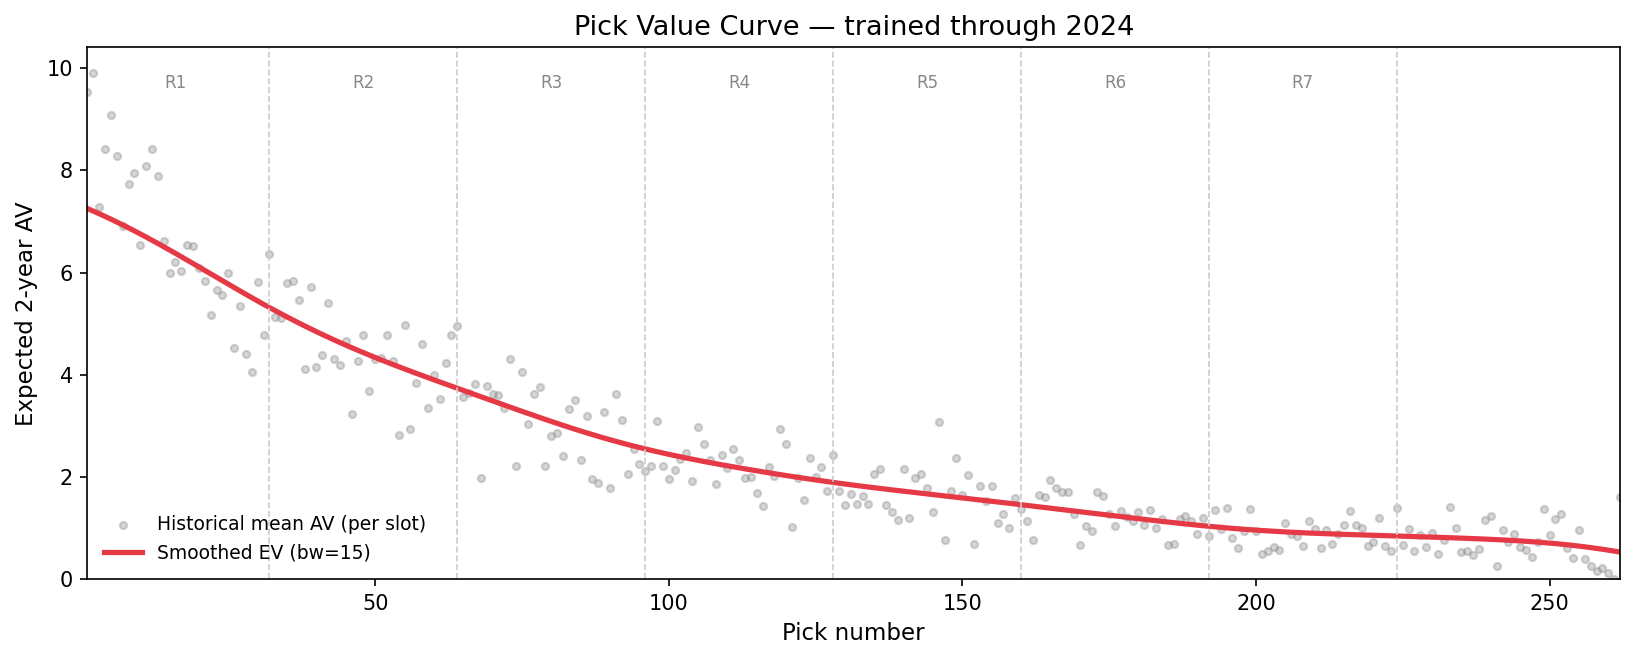

In [16]:
def build_pick_ev_table(train_picks: np.ndarray, train_av: np.ndarray,
                        bw: float = PV_BANDWIDTH, max_pick: int = 262) -> pd.Series:
    """Gaussian kernel smoother: expected AV at each pick slot."""
    picks_grid = np.arange(1, max_pick + 1)
    ev = np.empty(len(picks_grid))
    for i, p in enumerate(picks_grid):
        w = np.exp(-0.5 * ((train_picks - p) / bw) ** 2)
        w_sum = w.sum()
        ev[i] = float((train_av * w).sum() / w_sum) if w_sum > 1e-9 else 0.0
    return pd.Series(ev, index=picks_grid)


train_picks_arr = arts['train_aug']['pick'].to_numpy(dtype=float)
ev_table = build_pick_ev_table(train_picks_arr, arts['y_orig'])

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=150)

hist = (
    pd.DataFrame({'pick': train_picks_arr, 'av': arts['y_orig']})
    .groupby('pick')['av'].mean()
)
ax.scatter(hist.index, hist.values, s=12, alpha=0.35, color='#888888',
           label='Historical mean AV (per slot)')
ax.plot(ev_table.index, ev_table.values, lw=2.5, color='#E63946',
        label=f'Smoothed EV (bw={PV_BANDWIDTH})')

for r in range(1, 8):
    ax.axvline(r * 32, color='#CCCCCC', lw=0.8, ls='--')
    ax.text((r - 1) * 32 + 16, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 14,
            f'R{r}', ha='center', va='top', fontsize=8, color='#888888')

ax.set_xlabel('Pick number', fontsize=11)
ax.set_ylabel('Expected 2-year AV', fontsize=11)
ax.set_title(f'Pick Value Curve — trained through {train_df["draft_season"].max()}', fontsize=13)
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(1, 262)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 5 · Trade Fairness Evaluator

```python
evaluate_trade(
    side_a=[15, 48, 100],  # picks that Side A receives
    side_b=[5],            # picks that Side B receives
)
```

Pass exact pick numbers (int) or round shorthands `'r1'`–`'r7'`  
(mapped to the median pick of that round: 16, 48, 80, 112, 144, 176, 208).

  TRADE EVALUATION
             Side  Pick  Expected_AV
Team A (receives)    10         6.76
Team A (receives)    42         4.74
Team B (receives)     3         7.15
----------------------------------------------------
  Team A (receives) total EV : 11.50
  Team B (receives) total EV : 7.15
  Surplus         : 4.35 AV  →  Team A (receives) wins


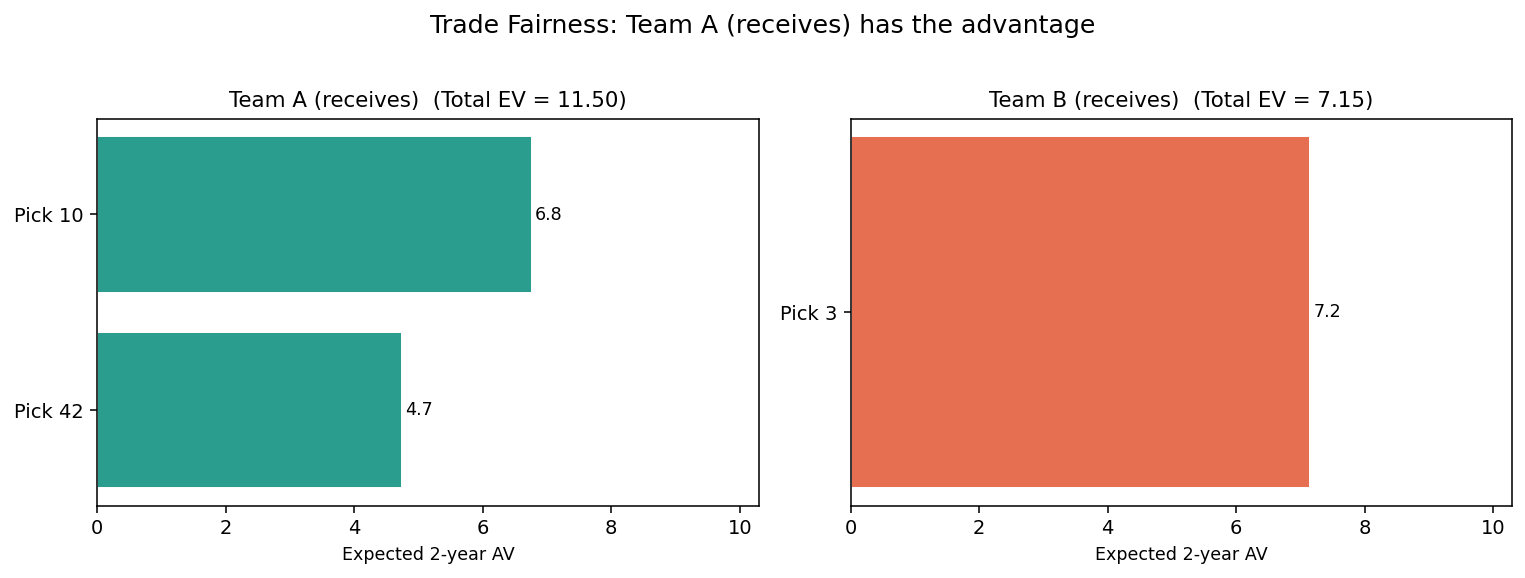

In [17]:
_ROUND_MEDIAN = {f'r{r}': (r - 1) * 32 + 16 for r in range(1, 8)}


def _resolve_pick(p) -> int:
    if isinstance(p, str):
        key = p.strip().lower()
        if key not in _ROUND_MEDIAN:
            raise ValueError(f"Unknown pick spec '{p}'. Use an int or 'r1'–'r7'.")
        return _ROUND_MEDIAN[key]
    return int(p)


def evaluate_trade(
    side_a: list,
    side_b: list,
    ev_table: pd.Series = ev_table,
    label_a: str = 'Side A',
    label_b: str = 'Side B',
) -> pd.DataFrame:
    """
    Compare expected 2-year AV for two sets of draft pick assets.

    Parameters
    ----------
    side_a, side_b : list of pick numbers (int) or round shorthands ('r1'–'r7')
    """
    rows = []
    for side_label, picks_raw in [(label_a, side_a), (label_b, side_b)]:
        for p_raw in picks_raw:
            p  = _resolve_pick(p_raw)
            ev = float(ev_table.get(p, ev_table.iloc[-1]))
            rows.append({'Side': side_label, 'Pick': p, 'Expected_AV': round(ev, 2)})

    detail = pd.DataFrame(rows)
    totals = detail.groupby('Side')['Expected_AV'].sum()
    ev_a   = totals.get(label_a, 0.0)
    ev_b   = totals.get(label_b, 0.0)
    surplus = ev_a - ev_b
    winner  = label_a if surplus > 0 else (label_b if surplus < 0 else 'Even')

    print('=' * 52)
    print('  TRADE EVALUATION')
    print('=' * 52)
    print(detail.to_string(index=False))
    print('-' * 52)
    print(f'  {label_a} total EV : {ev_a:.2f}')
    print(f'  {label_b} total EV : {ev_b:.2f}')
    print(f'  Surplus         : {abs(surplus):.2f} AV  →  {winner} wins')
    print('=' * 52)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=140)
    for ax, (lbl, color) in zip(axes, [(label_a, '#2A9D8F'), (label_b, '#E76F51')]):
        sub = detail[detail['Side'] == lbl]
        bars = ax.barh([f'Pick {r["Pick"]}' for _, r in sub.iterrows()],
                       sub['Expected_AV'], color=color, edgecolor='white')
        for bar, val in zip(bars, sub['Expected_AV']):
            ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}', va='center', fontsize=9)
        ax.set_title(f'{lbl}  (Total EV = {totals.get(lbl, 0):.2f})', fontsize=11)
        ax.set_xlabel('Expected 2-year AV', fontsize=9)
        ax.set_xlim(0, detail['Expected_AV'].max() * 1.3 + 1)
        ax.invert_yaxis()

    plt.suptitle(f'Trade Fairness: {winner} has the advantage', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    return detail


# ── Example: pick 3 for picks 10 + 42 ─────────────────────────────────────────
_ = evaluate_trade(
    side_a=[10, 42],
    side_b=[3],
    label_a='Team A (receives)',
    label_b='Team B (receives)',
)

  TRADE EVALUATION
  Side  Pick  Expected_AV
Team A    16         6.38
Team A    80         3.09
Team B    16         6.38
Team B    48         4.43
Team B   144         1.67
----------------------------------------------------
  Team A total EV : 9.47
  Team B total EV : 12.48
  Surplus         : 3.01 AV  →  Team B wins


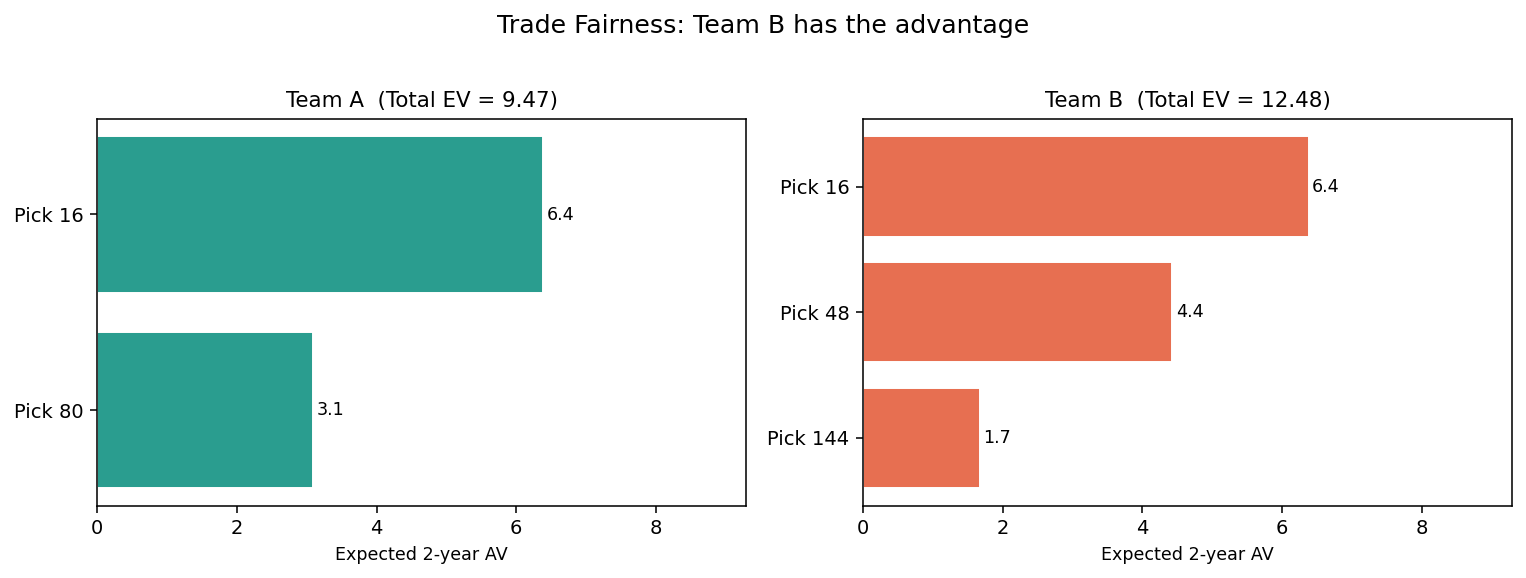

In [18]:
# Example with round shorthands
_ = evaluate_trade(
    side_a=['r1', 'r3'],
    side_b=['r1', 'r2', 'r5'],
    label_a='Team A',
    label_b='Team B',
)

## 6 · Player AV Predictor

Looks up a player from the target draft class and predicts their 2-year AV.

In [19]:
def _predict_rows(arts: dict, X: pd.DataFrame) -> dict:
    """Run feature-engineered rows through XGB, CatBoost, RF, FTT + ensemble."""
    # XGBoost — Tweedie, original scale
    xgb_p = np.clip(arts['xgb'].predict(X), 0.0, AV_MAX)

    # CatBoost — Tweedie, original scale
    X_cb = X[arts['cb_cols']].copy()
    cat_names = [arts['cb_cols'][i] for i in arts['cb_cat_idx']]
    for c in cat_names:
        X_cb[c] = X_cb[c].fillna('nan').astype(str)
    cb_p = np.clip(arts['catboost'].predict(X_cb), 0.0, AV_MAX)

    # Random Forest — log1p scale, back-transform
    rf_p = np.expm1(np.clip(arts['rf'].predict(X), *LOG_PRED_CLIP))

    # FTT — look up precomputed predictions by DataFrame index
    ftt_p = np.clip(arts['ftt_pred'].loc[X.index].to_numpy(), 0.0, AV_MAX)

    ensemble = np.clip((xgb_p + cb_p + rf_p + ftt_p) / 4.0, 0.0, AV_MAX)

    return {
        'XGBoost':        xgb_p,
        'CatBoost':       cb_p,
        'Random Forest':  rf_p,
        'FT-Transformer': ftt_p,
        'Ensemble':       ensemble,
    }


def predict_player_av(query: 'str | int', arts: dict = arts) -> pd.DataFrame:
    """
    Predict 2-year AV for a player from the target draft class.

    query : player name substring (case-insensitive) OR exact pick number (int)
    """
    pred_aug  = arts['pred_aug']
    feat_cols = arts['feat_cols']

    if isinstance(query, int):
        mask = pred_aug['pick'] == query
    else:
        mask = pred_aug['pfr_player_name'].str.contains(str(query), case=False, na=False)

    matches = pred_aug[mask]
    if matches.empty:
        raise ValueError(
            f"No player found for query='{query}' in the {PREDICT_YEAR} draft class."
        )
    if len(matches) > 1:
        print(f'Multiple matches ({len(matches)}):')
        print(matches[['pfr_player_name', 'pick', 'position_group', 'college']].to_string(index=False))

    preds = _predict_rows(arts, matches[feat_cols].copy())

    info_cols = ['pfr_player_name', 'pick', 'round', 'position', 'position_group', 'college', 'av_2yr']
    info = matches[[c for c in info_cols if c in matches.columns]].copy()

    pred_rows = []
    for i, (_, player) in enumerate(info.iterrows()):
        name   = player.get('pfr_player_name', '?')
        pick   = int(player.get('pick', 0))
        actual = player.get('av_2yr', np.nan)
        row = {'Player': name, 'Pick': pick}
        for m, arr in preds.items():
            row[m] = round(float(arr[i]), 2)
        row['Actual_AV'] = round(float(actual), 2) if pd.notna(actual) else 'N/A'
        pred_rows.append(row)

    result = pd.DataFrame(pred_rows)

    print('=' * 70)
    print(f'  PLAYER AV PREDICTION  ({PREDICT_YEAR} draft class)')
    print('=' * 70)
    print(result.to_string(index=False))
    print('=' * 70)

    MODEL_COLORS_NB = {
        'XGBoost':        '#2A9D8F',
        'CatBoost':       '#E9C46A',
        'Random Forest':  '#F4A261',
        'FT-Transformer': '#9B59B6',
        'Ensemble':       '#E63946',
    }
    model_names = list(MODEL_COLORS_NB.keys())

    for _, pr in result.iterrows():
        model_preds = [pr[m] for m in model_names]
        colors      = [MODEL_COLORS_NB[m] for m in model_names]

        fig, ax = plt.subplots(figsize=(9, 3.5), dpi=140)
        bars = ax.bar(model_names, model_preds, color=colors, edgecolor='white', width=0.55)
        for bar, val in zip(bars, model_preds):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=10)

        actual = pr['Actual_AV']
        if actual != 'N/A':
            ax.axhline(float(actual), color='#333333', lw=1.8, ls='--',
                       label=f'Actual AV = {actual}')
            ax.legend(frameon=False, fontsize=9)

        ev = round(float(ev_table.get(int(pr['Pick']), 0)), 2)
        ax.set_title(
            f"{pr['Player']}  |  Pick {pr['Pick']}  |  Pick EV = {ev}",
            fontsize=11,
        )
        ax.set_ylabel('Predicted 2-year AV', fontsize=9)
        top = max(model_preds + [float(actual) if actual != 'N/A' else 0]) * 1.3 + 1
        ax.set_ylim(0, top)
        ax.tick_params(axis='x', labelsize=8)
        plt.tight_layout()
        plt.show()

    return result

### 6a · Look up by pick number

  PLAYER AV PREDICTION  (2026 draft class)
          Player  Pick  XGBoost  CatBoost  Random Forest  FT-Transformer  Ensemble Actual_AV
Fernando Mendoza     1    13.05     14.93          13.54           14.21     13.93       N/A


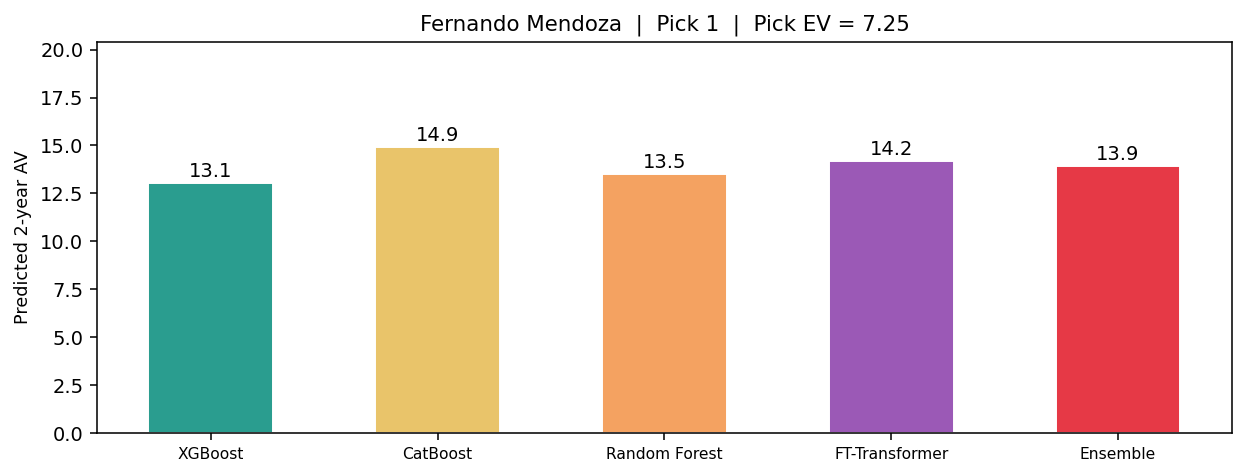

In [20]:
_ = predict_player_av(1)   # overall #1 pick

### 6b · Look up by name substring

  PLAYER AV PREDICTION  (2026 draft class)
          Player  Pick  XGBoost  CatBoost  Random Forest  FT-Transformer  Ensemble Actual_AV
Fernando Mendoza     1    13.05     14.93          13.54           14.21     13.93       N/A


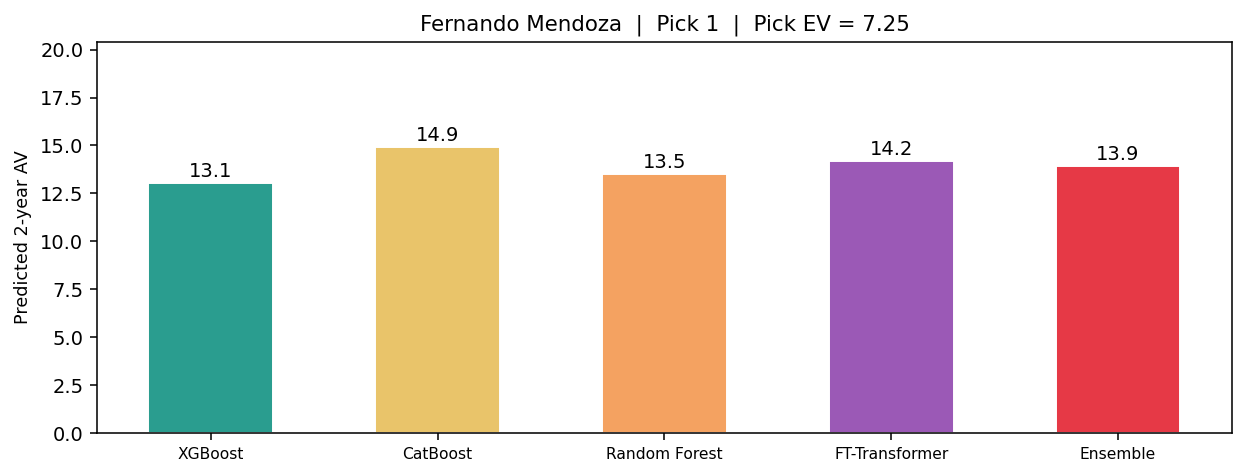

In [21]:
_ = predict_player_av('Mendoza')   # Fernando Mendoza, 2026 #1 overall

### 6c · Full draft class predictions

In [22]:
pred_aug  = arts['pred_aug']
feat_cols = arts['feat_cols']
preds     = _predict_rows(arts, pred_aug[feat_cols].copy())

info_cols = ['pfr_player_name', 'pick', 'round', 'position', 'position_group', 'college', 'av_2yr']
draft_class = pred_aug[[c for c in info_cols if c in pred_aug.columns]].copy()
for m, arr in preds.items():
    draft_class[m] = arr.round(2)
draft_class = draft_class.sort_values('pick').reset_index(drop=True)

print(f'{PREDICT_YEAR} draft class — {len(draft_class)} picks')

if has_labels and draft_class['av_2yr'].notna().any():
    from sklearn.metrics import mean_absolute_error
    mask_lbl = draft_class['av_2yr'].notna()
    for m in ['XGBoost', 'CatBoost', 'Random Forest', 'FT-Transformer', 'Ensemble']:
        mae = mean_absolute_error(draft_class.loc[mask_lbl, 'av_2yr'],
                                   draft_class.loc[mask_lbl, m])
        print(f'  {m:15s}  MAE = {mae:.3f}')
else:
    print('  (No AV labels available — MAE cannot be computed)')

draft_class.head(30)

2026 draft class — 257 picks
  (No AV labels available — MAE cannot be computed)


,pfr_player_name,pick,round,position,position_group,college,av_2yr,XGBoost,CatBoost,Random Forest,FT-Transformer,Ensemble
0,Fernando Mendoza,1,1,QB,QB,Indiana,NaN,13.05,14.93,13.54,14.21,13.93
1,David Bailey,2,1,DE,DL,Texas Tech,NaN,13.23,12.81,13.44,13.34,13.21
2,Jeremiyah Love,3,1,RB,RB,Notre Dame,NaN,14.90,15.02,13.34,13.48,14.18
3,Carnell Tate,4,1,WR,WR,Ohio St.,NaN,11.57,13.28,12.30,13.67,12.70
4,Arvell Reese,5,1,LB,LB,Ohio St.,NaN,13.39,14.38,12.83,13.80,13.60
5,Mansoor Delane,6,1,CB,DB,LSU,NaN,11.77,12.14,10.81,13.14,11.96
6,Sonny Styles,7,1,LB,LB,Ohio St.,NaN,13.89,12.68,13.25,11.61,12.86
7,Jordyn Tyson,8,1,WR,WR,Arizona St.,NaN,10.86,12.51,10.45,10.65,11.12
8,Spencer Fano,9,1,OT,OL,Utah,NaN,12.08,14.22,11.00,13.85,12.79
9,Francis Mauigoa,10,1,OT,OL,Miami (FL),NaN,12.32,12.65,10.31,13.20,12.12
